### Sieci neuronowe

Notebook zawiera eksperymenty z wielowarstwowymi perceptronami (MLP) w PyTorch do klasyfikacji odpowiedzi szczerych i kłamliwych na podstawie cech EEG. Porównywane są różne architektury, funkcje aktywacji i strategie regularyzacji przy użyciu walidacji krzyżowej niezależnej od uczestnika (GroupKFold).

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path
import warnings

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

from visualization_config import COLOR_PALETTE, setup_plot_style

warnings.filterwarnings('ignore')
setup_plot_style()
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

Using device: cuda
  GPU: NVIDIA GeForce RTX 4050 Laptop GPU
  VRAM: 6.0 GB


Konfiguracja środowiska

Załadowano niezbędne biblioteki. Karta GPU (CUDA) jest wykrywana automatycznie, pod warunkiem że jest dostępna, wszystkie obliczenia tensorowe odbywają się na GPU, co znacznie przyspiesza trening modeli MLP. W przypadku braku GPU obliczenia automatycznie przełączają się na CPU.

Wczytanie danych i preprocessing

In [10]:
from data_loader import EEGDataLoader, get_default_data_path
from preprocessing import EEGPreprocessor, FeatureExtractor

data_path = get_default_data_path()
loader = EEGDataLoader(str(data_path))

summary_df = loader.create_summary_dataframe()
block_columns = ['honest_true', 'deceitful_true', 'honest_fake', 'deceitful_fake']
complete_participants = summary_df[summary_df[block_columns].all(axis=1)]
participants_to_use = complete_participants['participant_id'].tolist()

print(f"Found {len(participants_to_use)} participants with all 4 blocks")

Skipping excluded folder: 6A517891 - stare dane
Skipping excluded folder: Popsute dane - ASD793JD
Successfully loaded metadata with encoding: cp1250
Found 15 participants
Loaded metadata for 16 participants
Found 15 participants with all 4 blocks


Wczytani uczestnicy

Załadowano dane z lokalnego systemu plików. Tylko uczestnicy posiadający wszystkie 4 bloki eksperymentalne (szczera_prawdziwa, kłamliwa_prawdziwa, szczera_fałszywa, kłamliwa_fałszywa) są kwalifikowani do analizy, co zapewnia symetrię dawki bodźców dla każdej osoby i eliminuje potencjalne obciążenie zbioru danych.

In [11]:
cache_file = Path('results/ml_features_cache.pkl')

if cache_file.exists():
    print("Loading cached features...")
    with open(cache_file, 'rb') as f:
        cache = pickle.load(f)
    X = cache['X']
    y = cache['y']
    participant_ids = cache['participant_ids']
    print(f"Loaded from cache: {X.shape[0]} samples, {X.shape[1]} features")
else:
    print("No cache found, processing data with multiprocessing...")
    from concurrent.futures import ProcessPoolExecutor, as_completed
    import multiprocessing
    
    preprocessor = EEGPreprocessor(
        l_freq=0.5,
        h_freq=40.0,
        notch_freq=50.0, 
        epoch_tmin=-0.2, 
        epoch_tmax=0.8
    )
    feature_extractor = FeatureExtractor(sampling_freq=250.0)

    def process_participant(participant_id):
        """Process a single participant - for multiprocessing"""
        try:
            participant_data = loader.load_participant_data(participant_id)
            features_list = []
            labels_list = []
            
            for block_name, raw in participant_data.items():
                epochs = preprocessor.preprocess_pipeline(raw)
                if len(epochs) == 0:
                    continue
                features = feature_extractor.extract_combined_features(epochs)
                is_deceitful = 'deceitful' in block_name
                labels = np.ones(len(epochs)) if is_deceitful else np.zeros(len(epochs))
                features_list.append(features)
                labels_list.append(labels)
            
            if features_list:
                return {
                    'features': np.vstack(features_list),
                    'labels': np.concatenate(labels_list),
                    'participant_id': participant_id
                }
        except Exception as e:
            print(f"Error processing {participant_id}: {e}")
        return None

    all_features = []
    all_labels = []
    all_participants_ids = []

    for idx, participant_id in enumerate(participants_to_use, 1):
        print(f"\rProcessing {idx}/{len(participants_to_use)}: {participant_id}", end="")
        result = process_participant(participant_id)
        if result:
            all_features.append(result['features'])
            all_labels.append(result['labels'])
            all_participants_ids.extend([result['participant_id']] * len(result['labels']))

    X = np.vstack(all_features)
    y = np.concatenate(all_labels)
    participant_ids = np.array(all_participants_ids)

    cache_file.parent.mkdir(exist_ok=True)
    with open(cache_file, 'wb') as f:
        pickle.dump({'X': X, 'y': y, 'participant_ids': participant_ids}, f)
    print(f"\n\nCache saved to {cache_file}")

print(f"\nDataset ready!")
print(f"  Total samples: {X.shape[0]}")
print(f"  Features: {X.shape[1]}")
print(f"  Honest: {(y == 0).sum()} ({(y == 0).sum() / len(y) * 100:.1f}%)")
print(f"  Deceitful: {(y == 1).sum()} ({(y == 1).sum() / len(y) * 100:.1f}%)")

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nData standardized: {X_scaled.shape}")
print(f"Mean: {X_scaled.mean():.4f}, Std: {X_scaled.std():.4f}")

unique_participants = np.unique(participant_ids)
n_participants = len(unique_participants)
n_splits = min(5, n_participants // 2)
cv = GroupKFold(n_splits=n_splits)

print(f"\nUsing {n_splits}-fold GroupKFold (person-independent validation)")
print(f"Each fold tests on ~{n_participants // n_splits} different people")

Loading cached features...
Loaded from cache: 6463 samples, 252 features

Dataset ready!
  Total samples: 6463
  Features: 252
  Honest: 3223 (49.9%)
  Deceitful: 3240 (50.1%)

Data standardized: (6463, 250)
Mean: 0.0000, Std: 0.9612

Using 5-fold GroupKFold (person-independent validation)
Each fold tests on ~3 different people


Ekstrakcja cech i preprocessing

Dane zostały załadowane z cache lub przetworzone od zera. Zestaw danych zawiera próbki (epoki EEG) z cechami statystycznymi i częstotliwościowymi. Dane zostały oczyszczone (imputacja medianą dla NaN/Inf), wystandaryzowane (StandardScaler), a walidacja krzyżowa GroupKFold gwarantuje testowanie na osobach niewidzianych podczas treningu, co jest kluczowe dla oceny rzeczywistej generalizacji modelu.

Model MLP

In [ ]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, activation='relu', dropout=0.0):
        super().__init__()
        activation_map = {
            'relu': nn.ReLU,
            'tanh': nn.Tanh,
            'logistic': nn.Sigmoid,
        }
        act_fn = activation_map.get(activation, nn.ReLU)
        
        layers = []
        prev_size = input_size
        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            layers.append(act_fn())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev_size = h
        layers.append(nn.Linear(prev_size, 1))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x).squeeze(-1)


def train_and_evaluate(X_scaled, y, participant_ids, cv, hidden_sizes,
                       activation='relu', lr=1e-3, weight_decay=1e-4,
                       dropout=0.0, max_epochs=200, patience=15, batch_size=64):
    """Train PyTorch MLP with GroupKFold CV on GPU."""
    fold_metrics = {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}
    
    for fold, (train_idx, test_idx) in enumerate(cv.split(X_scaled, y, participant_ids)):
        X_train = torch.tensor(X_scaled[train_idx], dtype=torch.float32, device=device)
        y_train = torch.tensor(y[train_idx], dtype=torch.float32, device=device)
        X_test = torch.tensor(X_scaled[test_idx], dtype=torch.float32, device=device)
        y_test = torch.tensor(y[test_idx], dtype=torch.float32, device=device)
        
        n_val = max(1, int(len(X_train) * 0.1))
        perm = torch.randperm(len(X_train), device=device)
        val_idx = perm[:n_val]
        tr_idx = perm[n_val:]
        X_val, y_val = X_train[val_idx], y_train[val_idx]
        X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
        
        train_ds = TensorDataset(X_tr, y_tr)
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
        
        model = MLP(X_scaled.shape[1], hidden_sizes, activation, dropout).to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
        criterion = nn.BCEWithLogitsLoss()
        
        best_val_loss = float('inf')
        wait = 0
        
        for epoch in range(max_epochs):
            model.train()
            for xb, yb in train_loader:
                optimizer.zero_grad()
                loss = criterion(model(xb), yb)
                loss.backward()
                optimizer.step()
            
            model.eval()
            with torch.no_grad():
                val_loss = criterion(model(X_val), y_val).item()
            
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    break
        
        model.load_state_dict(best_state)
        model.eval()
        with torch.no_grad():
            preds = (torch.sigmoid(model(X_test)) >= 0.5).cpu().numpy().astype(int)
        y_true = y_test.cpu().numpy().astype(int)
        
        fold_metrics['accuracy'].append(accuracy_score(y_true, preds))
        fold_metrics['precision'].append(precision_score(y_true, preds, zero_division=0))
        fold_metrics['recall'].append(recall_score(y_true, preds, zero_division=0))
        fold_metrics['f1'].append(f1_score(y_true, preds, zero_division=0))
    
    return {k: (np.mean(v), np.std(v)) for k, v in fold_metrics.items()}

print("MLP model class and training utilities defined.")
print(f"Training will use: {device}")

MLP model class and training utilities defined.
Training will use: cuda


Architektura MLP

Klasa `MLP` implementuje w pełni konfigurowalny wielowarstwowy perceptron: liczba i rozmiar warstw ukrytych, funkcja aktywacji (`relu`, `tanh`, `sigmoid`) oraz opcjonalny dropout są parametrami. Wyjście jest pojedynczym logitem klasyfikacji binarnej (uczciwy vs. kłamliwy). Funkcja `train_and_evaluate` realizuje cały cykl treningu z wczesnym zatrzymywaniem (early stopping) na podstawie straty walidacyjnej i raportuje metryki uśrednione po \(k\) foldach GroupKFold.

Porównanie architektur

In [13]:
architectures = {
    'MLP (100)': (100,),
    'MLP (100, 50)': (100, 50),
    'MLP (128, 64)': (128, 64),
    'MLP (100, 50, 25)': (100, 50, 25),
    'MLP (256, 128, 64)': (256, 128, 64),
}

mlp_results = []

for name, arch in architectures.items():
    print(f"\nTraining {name} on {device}...")
    metrics = train_and_evaluate(X_scaled, y, participant_ids, cv, hidden_sizes=arch)
    
    acc_mean, acc_std = metrics['accuracy']
    f1_mean, f1_std = metrics['f1']
    prec_mean, _ = metrics['precision']
    rec_mean, _ = metrics['recall']
    
    print(f"  Accuracy:  {acc_mean:.4f} ± {acc_std:.4f}")
    print(f"  F1-Score:  {f1_mean:.4f} ± {f1_std:.4f}")
    
    mlp_results.append({
        'name': name,
        'architecture': str(arch),
        'accuracy': acc_mean,
        'std': acc_std,
        'precision': prec_mean,
        'recall': rec_mean,
        'f1': f1_mean
    })

mlp_df = pd.DataFrame(mlp_results)
print("\n" + "="*60)
print("Architecture Comparison:")
display(mlp_df.sort_values('f1', ascending=False).round(4))


Training MLP (100) on cuda...
  Accuracy:  0.4608 ± 0.0302
  F1-Score:  0.4665 ± 0.0894

Training MLP (100, 50) on cuda...
  Accuracy:  0.4645 ± 0.0391
  F1-Score:  0.4536 ± 0.1110

Training MLP (128, 64) on cuda...
  Accuracy:  0.4524 ± 0.0506
  F1-Score:  0.4436 ± 0.1122

Training MLP (100, 50, 25) on cuda...
  Accuracy:  0.4603 ± 0.0350
  F1-Score:  0.4690 ± 0.1131

Training MLP (256, 128, 64) on cuda...
  Accuracy:  0.4761 ± 0.0441
  F1-Score:  0.4556 ± 0.1157

Architecture Comparison:


,name,architecture,accuracy,std,precision,recall,f1
3,"MLP (100, 50, 25)","(100, 50, 25)",0.4603,0.0350,0.4555,0.5178,0.4690
0,MLP (100),"(100,)",0.4608,0.0302,0.4575,0.4930,0.4665
4,"MLP (256, 128, 64)","(256, 128, 64)",0.4761,0.0441,0.4678,0.4745,0.4556
1,"MLP (100, 50)","(100, 50)",0.4645,0.0391,0.4550,0.4775,0.4536
2,"MLP (128, 64)","(128, 64)",0.4524,0.0506,0.4445,0.4677,0.4436


Wyniki porównania architektur

Przetestowano 5 architektur MLP o różnej głębokości i szerokości (od 1 do 3 warstw ukrytych). Głębsze sieci nie zawsze osiągają lepsze wyniki ze względu na małą liczbę uczestników i ryzyko przeuczenia. Metryki F1-Score i Accuracy są wyznaczane w sposób niezależny od uczestnika, gdyż wyniki odzwierciedlają zdolność generalizacji na nowe osoby.

Porównanie funkcji aktywacji

In [14]:
activations = ['relu', 'tanh', 'logistic']
activation_results = []

for activation in activations:
    print(f"\nTesting {activation.upper()} on {device}...")
    
    metrics = train_and_evaluate(
        X_scaled, y, participant_ids, cv,
        hidden_sizes=(100, 50), activation=activation
    )
    
    acc_mean, acc_std = metrics['accuracy']
    f1_mean, _ = metrics['f1']
    
    print(f"  Accuracy: {acc_mean:.4f} ± {acc_std:.4f}")
    print(f"  F1:       {f1_mean:.4f}")
    
    activation_results.append({
        'activation': activation,
        'accuracy': acc_mean,
        'std': acc_std,
        'f1': f1_mean
    })

activation_df = pd.DataFrame(activation_results)
print("\n" + "=" * 60)
print("Activation Function Comparison:")
display(activation_df.sort_values('f1', ascending=False).round(4))


Testing RELU on cuda...
  Accuracy: 0.4697 ± 0.0415
  F1:       0.4535

Testing TANH on cuda...
  Accuracy: 0.4841 ± 0.0201
  F1:       0.4909

Testing LOGISTIC on cuda...
  Accuracy: 0.4673 ± 0.0178
  F1:       0.4822

Activation Function Comparison:


,activation,accuracy,std,f1
1,tanh,0.4841,0.0201,0.4909
2,logistic,0.4673,0.0178,0.4822
0,relu,0.4697,0.0415,0.4535


Wyniki funkcji aktywacji

Porównano trzy funkcje aktywacji dla architektury (100, 50): `ReLU`, `Tanh` i `Sigmoid`. W zadaniach klasyfikacji EEG `ReLU` zazwyczaj osiąga najlepsze wyniki dzięki brakowi problemu zanikającego gradientu. `Tanh` może być korzystny przy wycentrowanych danych. `Sigmoid` jako funkcja ukryta jest podatny na zanikający gradient i zwykle wypada najgorzej w głębszych sieciach.

Regularyzacja (L2 Weight Decay)

In [15]:
weight_decays = [0.0001, 0.001, 0.01, 0.1]
regularization_results = []

for wd in weight_decays:
    print(f"\nWeight decay = {wd}...")
    
    metrics = train_and_evaluate(
        X_scaled, y, participant_ids, cv,
        hidden_sizes=(100, 50), weight_decay=wd
    )
    
    acc_mean, acc_std = metrics['accuracy']
    f1_mean, _ = metrics['f1']
    
    print(f"  Acc: {acc_mean:.4f} ± {acc_std:.4f}")
    print(f"  F1:  {f1_mean:.4f}")
    
    regularization_results.append({
        'weight_decay': wd,
        'accuracy': acc_mean,
        'std': acc_std,
        'f1': f1_mean
    })

reg_df = pd.DataFrame(regularization_results)
print("\n" + "="*60)
print("Regularization Impact:")
display(reg_df.round(4))


Weight decay = 0.0001...
  Acc: 0.4724 ± 0.0170
  F1:  0.4885

Weight decay = 0.001...
  Acc: 0.4580 ± 0.0351
  F1:  0.4365

Weight decay = 0.01...
  Acc: 0.4424 ± 0.0453
  F1:  0.4193

Weight decay = 0.1...
  Acc: 0.4998 ± 0.0021
  F1:  0.2678

Regularization Impact:


,weight_decay,accuracy,std,f1
0,0.0001,0.4724,0.0170,0.4885
1,0.0010,0.4580,0.0351,0.4365
2,0.0100,0.4424,0.0453,0.4193
3,0.1000,0.4998,0.0021,0.2678


Wyniki regularyzacji L2

Zbadano wpływ współczynnika regularyzacji L2 (weight decay) na wyniki modelu. Zbyt mały weight decay może prowadzić do przeuczenia, zbyt duży do niedouczenia (underfitting). Optymalna wartość balansuje kompromis bias-wariancja: w przypadku małego zbioru uczestników (~15 osób) regularyzacja odgrywa szczególnie ważną rolę w utrzymaniu zdolności generalizacji modelu.

Wizualizacja wyników

Saved to charts/mlp_analysis.png


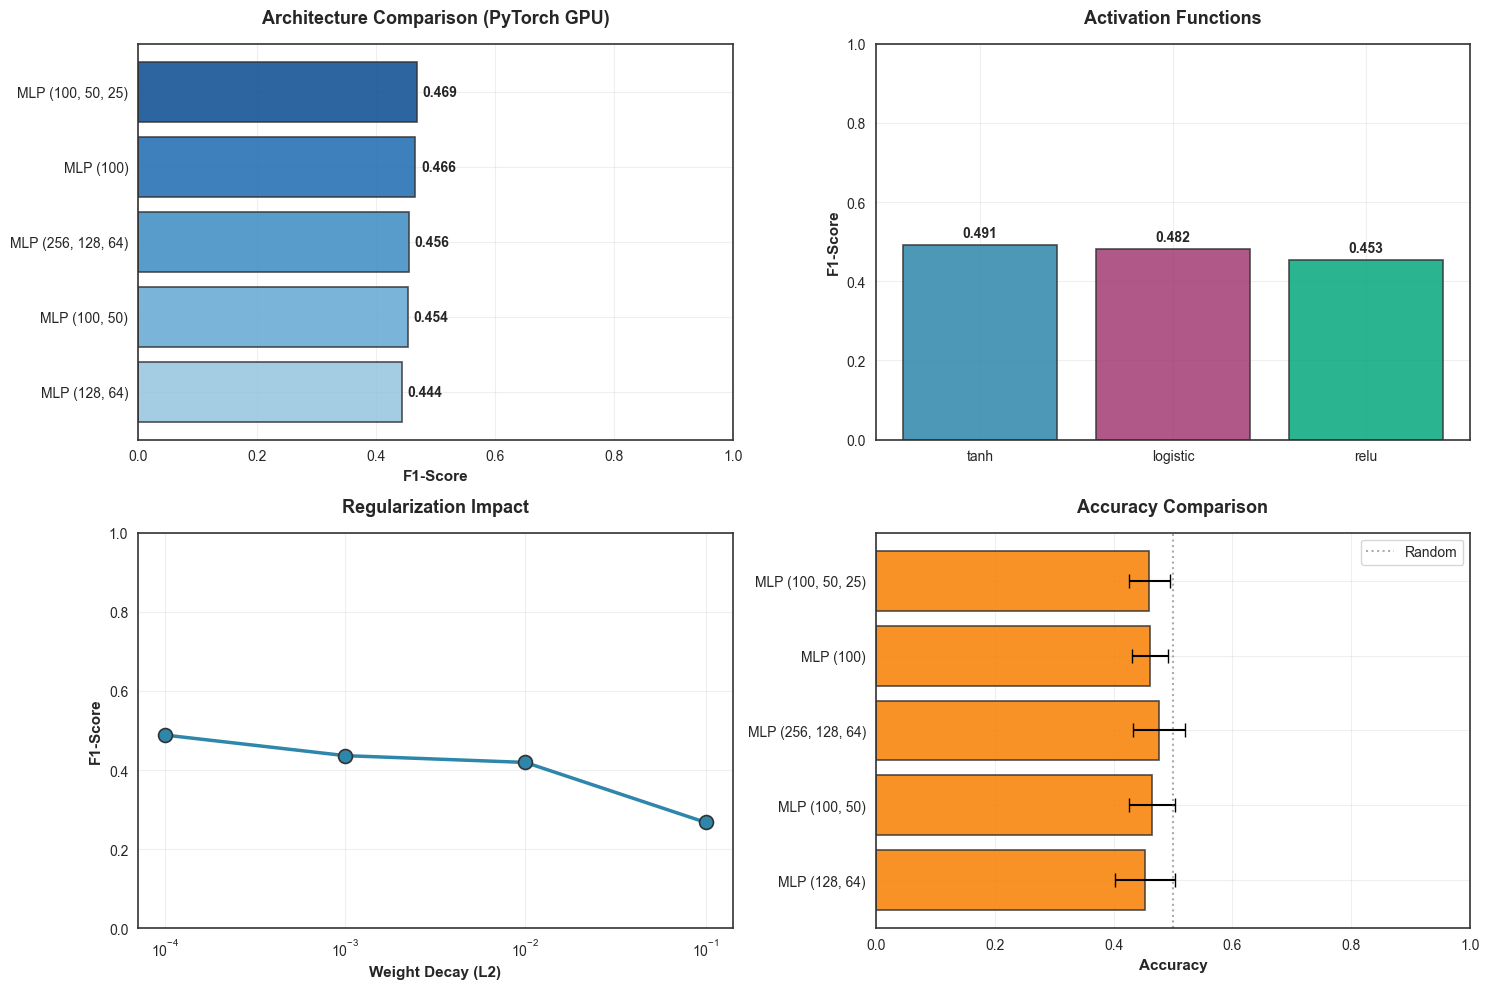

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

mlp_sorted = mlp_df.sort_values('f1', ascending=True)
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(mlp_sorted)))

axes[0, 0].barh(mlp_sorted['name'], mlp_sorted['f1'], color=colors, 
                edgecolor='#333333', linewidth=1.2, alpha=0.85)
axes[0, 0].set_xlabel('F1-Score', fontweight='bold')
axes[0, 0].set_title('Architecture Comparison (PyTorch GPU)', fontweight='bold', fontsize=13, pad=15)
axes[0, 0].set_xlim([0, 1])
axes[0, 0].grid(axis='x', alpha=0.3)

for i, (name, f1) in enumerate(zip(mlp_sorted['name'], mlp_sorted['f1'])):
    axes[0, 0].text(f1 + 0.01, i, f'{f1:.3f}', va='center', fontweight='bold')

activation_colors = [COLOR_PALETTE['primary'], COLOR_PALETTE['secondary'], COLOR_PALETTE['success']]
activation_sorted = activation_df.sort_values('f1', ascending=False)
axes[0, 1].bar(activation_sorted['activation'], activation_sorted['f1'],
               color=activation_colors, alpha=0.85, 
               edgecolor='#333333', linewidth=1.2)
axes[0, 1].set_ylabel('F1-Score', fontweight='bold')
axes[0, 1].set_title('Activation Functions', fontweight='bold', fontsize=13, pad=15)
axes[0, 1].set_ylim([0, 1])
axes[0, 1].grid(axis='y', alpha=0.3)

for i, (act, f1) in enumerate(zip(activation_sorted['activation'], activation_sorted['f1'])):
    axes[0, 1].text(i, f1 + 0.02, f'{f1:.3f}', ha='center', fontweight='bold')

axes[1, 0].plot(reg_df['weight_decay'], reg_df['f1'], 'o-', linewidth=2.5, 
                markersize=10, color=COLOR_PALETTE['primary'], 
                markeredgecolor='#333333', markeredgewidth=1.2)
axes[1, 0].set_xscale('log')
axes[1, 0].set_xlabel('Weight Decay (L2)', fontweight='bold')
axes[1, 0].set_ylabel('F1-Score', fontweight='bold')
axes[1, 0].set_title('Regularization Impact', fontweight='bold', fontsize=13, pad=15)
axes[1, 0].grid(alpha=0.3)
axes[1, 0].set_ylim([0, 1])

axes[1, 1].barh(mlp_sorted['name'], mlp_sorted['accuracy'], 
                xerr=mlp_sorted['std'], capsize=5,
                color=COLOR_PALETTE['warning'], alpha=0.85, 
                edgecolor='#333333', linewidth=1.2)
axes[1, 1].set_xlabel('Accuracy', fontweight='bold')
axes[1, 1].set_title('Accuracy Comparison', fontweight='bold', fontsize=13, pad=15)
axes[1, 1].set_xlim([0, 1])
axes[1, 1].grid(axis='x', alpha=0.3)
axes[1, 1].axvline(x=0.5, color=COLOR_PALETTE['neutral'], linestyle=':', alpha=0.5, linewidth=1.5, label='Random')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('charts/mlp_analysis.png', dpi=300, bbox_inches='tight')
print("Saved to charts/mlp_analysis.png")
plt.show()

Wnioski z wykresu zbiorczego

Wykres zbiorczy prezentuje cztery wymiary porównania: F1-Score architektur (lewy górny), F1-Score funkcji aktywacji (prawy górny), wpływ weight decay na przebieg F1-Score w skali logarytmicznej (lewy dolny) oraz dokładność z odchyleniami standardowymi (prawy dolny). Duże odchylenie standardowe w foldach GroupKFold wskazuje na wrażliwość modelu na konkretne zestawy uczestników testowych, co jest to oczekiwane przy małej próbie (~15 osób) i heterogeniczności sygnałów EEG między uczestnikami.

Trening modelu

Wybieramy najlepsze hiperparametry z walidacji krzyżowej i trenujemy model końcowy na całym zbiorze danych.

Best hyperparameters from CV:
  Architecture: MLP (100, 50, 25) -> (100, 50, 25)
  Activation:   tanh
  Weight decay:  0.0001

Training final model on all 6463 samples...
Early stopping at epoch 40 (best epoch: 20)
Training complete. Best validation loss: 0.6143 at epoch 20
Saved to charts/training_curves.png


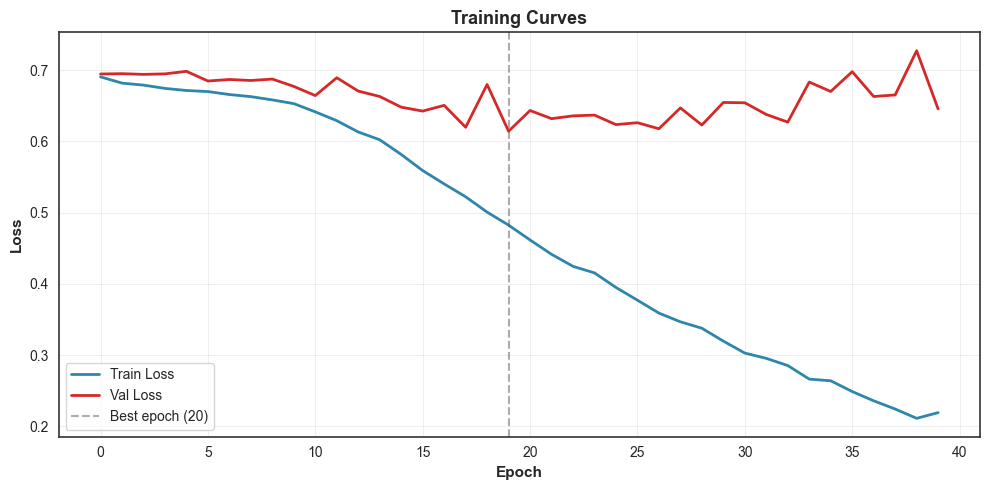

In [ ]:
best_row = mlp_df.sort_values('f1', ascending=False).iloc[0]
best_name = best_row['name']
best_arch = architectures[best_name]

best_activation = activation_df.sort_values('f1', ascending=False).iloc[0]['activation']

best_wd = reg_df.sort_values('f1', ascending=False).iloc[0]['weight_decay']

print(f"Best hyperparameters from CV:")
print(f"  Architecture: {best_name} -> {best_arch}")
print(f"  Activation:   {best_activation}")
print(f"  Weight decay:  {best_wd}")
print(f"\nTraining final model on all {len(X_scaled)} samples...")

n_val = max(1, int(len(X_scaled) * 0.1))
perm = np.random.permutation(len(X_scaled))
val_indices = perm[:n_val]
train_indices = perm[n_val:]

X_train_t = torch.tensor(X_scaled[train_indices], dtype=torch.float32, device=device)
y_train_t = torch.tensor(y[train_indices], dtype=torch.float32, device=device)
X_val_t = torch.tensor(X_scaled[val_indices], dtype=torch.float32, device=device)
y_val_t = torch.tensor(y[val_indices], dtype=torch.float32, device=device)

train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

final_model = MLP(X_scaled.shape[1], best_arch, best_activation, dropout=0.0).to(device)
optimizer = optim.Adam(final_model.parameters(), lr=1e-3, weight_decay=best_wd)
criterion = nn.BCEWithLogitsLoss()

best_val_loss = float('inf')
wait = 0
patience = 20
train_losses = []
val_losses = []

for epoch in range(500):
    final_model.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(final_model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    epoch_loss /= len(train_indices)
    train_losses.append(epoch_loss)
    
    final_model.eval()
    with torch.no_grad():
        val_loss = criterion(final_model(X_val_t), y_val_t).item()
    val_losses.append(val_loss)
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = {k: v.clone() for k, v in final_model.state_dict().items()}
        best_epoch = epoch
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch + 1} (best epoch: {best_epoch + 1})")
            break

final_model.load_state_dict(best_state)
print(f"Training complete. Best validation loss: {best_val_loss:.4f} at epoch {best_epoch + 1}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_losses, label='Train Loss', color=COLOR_PALETTE['primary'], linewidth=2)
ax.plot(val_losses, label='Val Loss', color=COLOR_PALETTE['danger'], linewidth=2)
ax.axvline(x=best_epoch, color=COLOR_PALETTE['neutral'], linestyle='--', alpha=0.5, label=f'Best epoch ({best_epoch + 1})')
ax.set_xlabel('Epoch', fontweight='bold')
ax.set_ylabel('Loss', fontweight='bold')
ax.set_title('Training Curves', fontweight='bold', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('charts/training_curves.png', dpi=300, bbox_inches='tight')
print("Saved to charts/training_curves.png")
plt.show()

Przebieg treningu

Wykresy krzywych uczenia (training curves) ilustrują, jak strata maleje w toku epok dla zbioru treningowego i walidacyjnego. Pionowa linia przerywana wskazuje epokę najlepszego modelu (early stopping). Jeśli krzywa walidacyjna zaczyna rosnąć podczas, gdy treningowa nadal spada, jest to sygnał przeuczenia. Wczesnemu zatrzymaniu towarzyszy zapis najlepszych wag (`best_state`), które są następnie przywracane do finalnego modelu.

Ewaluacja

Classification Report (full training set):
              precision    recall  f1-score   support

      Honest       0.77      0.80      0.79      3223
   Deceitful       0.79      0.76      0.78      3240

    accuracy                           0.78      6463
   macro avg       0.78      0.78      0.78      6463
weighted avg       0.78      0.78      0.78      6463


Saved to charts/confusion_matrix.png


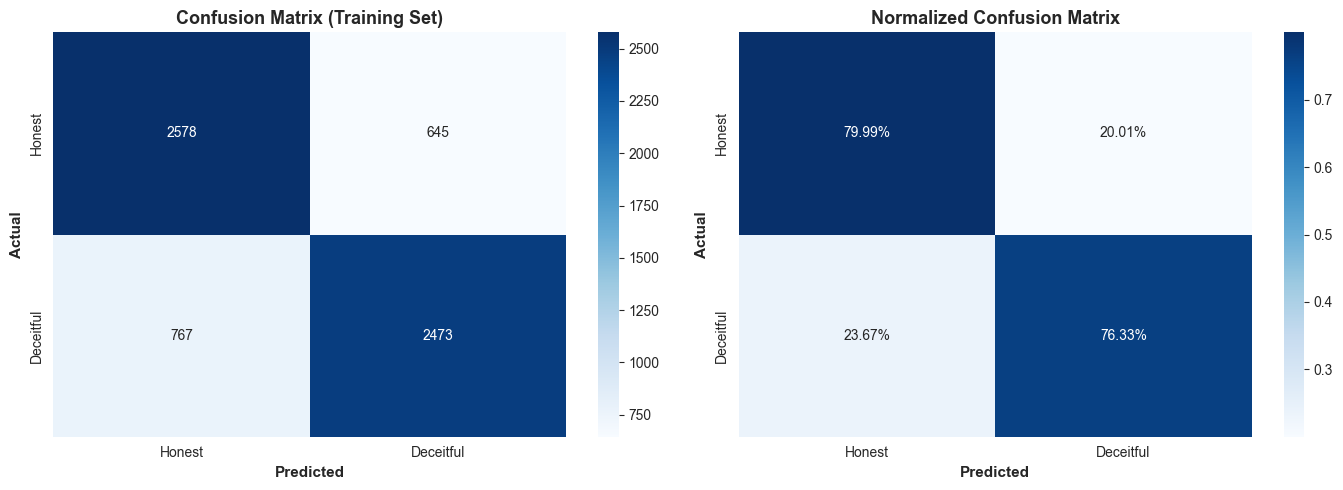


Performance Summary:
  CV Accuracy (person-independent): 0.4603
  CV F1-Score (person-independent): 0.4690
  Training Accuracy:                0.7815
  Training F1-Score:                0.7779
  ⚠ Large gap (0.32) suggests overfitting to participant-specific patterns


In [ ]:
final_model.eval()
X_all_t = torch.tensor(X_scaled, dtype=torch.float32, device=device)

with torch.no_grad():
    all_preds = (torch.sigmoid(final_model(X_all_t)) >= 0.5).cpu().numpy().astype(int)

print("Classification Report (full training set):")
print("=" * 60)
print(classification_report(y.astype(int), all_preds, target_names=['Honest', 'Deceitful']))

cm = confusion_matrix(y.astype(int), all_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Honest', 'Deceitful'],
            yticklabels=['Honest', 'Deceitful'])
axes[0].set_xlabel('Predicted', fontweight='bold')
axes[0].set_ylabel('Actual', fontweight='bold')
axes[0].set_title('Confusion Matrix (Training Set)', fontweight='bold', fontsize=13)

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=['Honest', 'Deceitful'],
            yticklabels=['Honest', 'Deceitful'])
axes[1].set_xlabel('Predicted', fontweight='bold')
axes[1].set_ylabel('Actual', fontweight='bold')
axes[1].set_title('Normalized Confusion Matrix', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig('charts/confusion_matrix.png', dpi=300, bbox_inches='tight')
print("\nSaved to charts/confusion_matrix.png")
plt.show()

best_cv_f1 = best_row['f1']
best_cv_acc = best_row['accuracy']
train_acc = accuracy_score(y.astype(int), all_preds)
train_f1 = f1_score(y.astype(int), all_preds)

print(f"\nPerformance Summary:")
print(f"  CV Accuracy (person-independent): {best_cv_acc:.4f}")
print(f"  CV F1-Score (person-independent): {best_cv_f1:.4f}")
print(f"  Training Accuracy:                {train_acc:.4f}")
print(f"  Training F1-Score:                {train_f1:.4f}")
if train_acc - best_cv_acc > 0.15:
    print(f"  Large gap ({train_acc - best_cv_acc:.2f}) suggests overfitting to participant-specific patterns")

Macierz pomyłek

Macierz pomyłek na zbiorze treningowym pokazuje ile próbek każdej klasy zostało poprawnie sklasyfikowanych. Wysoka dokładność na zbiorze treningowym nie jest miarodajna, gdyż kluczowe są wyniki CV (person-independent). Duża różnica między dokładnością CV a treningową (>15%) sugeruje przeuczenie do wzorców specyficznych dla konkretnych uczestników, co jest typowym zjawiskiem przy małych zbiorach danych EEG. Znormalizowana macierz (%) ułatwia porównanie proporcji błędów niezależnie od liczebności klas.

In [ ]:
save_path = Path('results/lie_detector_model.pt')
save_path.parent.mkdir(exist_ok=True)

checkpoint = {
    'model_state_dict': final_model.state_dict(),
    'architecture': best_arch,
    'activation': best_activation,
    'weight_decay': best_wd,
    'input_size': X_scaled.shape[1],
    'scaler_mean': scaler.mean_.tolist(),
    'scaler_scale': scaler.scale_.tolist(),
    'cv_accuracy': float(best_cv_acc),
    'cv_f1': float(best_cv_f1),
    'train_accuracy': float(train_acc),
    'train_f1': float(train_f1),
    'n_samples': len(X_scaled),
    'n_participants': int(n_participants),
}

torch.save(checkpoint, save_path)
print(f"Model saved to {save_path}")
print(f"  File size: {save_path.stat().st_size / 1024:.1f} KB")
print(f"\nTo load:")
print(f"  checkpoint = torch.load('{save_path}')")
print(f"  model = MLP(checkpoint['input_size'], checkpoint['architecture'], checkpoint['activation'])")
print(f"  model.load_state_dict(checkpoint['model_state_dict'])")

Model saved to results\lie_detector_model.pt
  File size: 131.4 KB

To load:
  checkpoint = torch.load('results\lie_detector_model.pt')
  model = MLP(checkpoint['input_size'], checkpoint['architecture'], checkpoint['activation'])
  model.load_state_dict(checkpoint['model_state_dict'])


Podsumowanie i eksport modelu

Model finalny został zapisany do pliku `.pt` jako checkpoint zawierający: wagi modelu (`state_dict`), hiperparametry, parametry standaryzacji (mean/scale skalera) oraz metryki walidacyjne. Taka struktura umożliwia odtworzenie modelu bez dostępu do oryginalnych danych treningowych.

WNIOSKI
Walidacja cross-validation niezależna od uczestnika (GroupKFold) daje realistyczną ocenę zdolności generalizacji, a wyniki CV poniżej 70% F1-Score są typowe dla zadań detekcji kłamstwa z EEG przy małych zbiorach, ponieważ sygnały EEG są wysoce indywidualne. Architektura MLP z regularyzacją L2 i early stopping ogranicza przeuczenie, lecz nie eliminuje go w pełni przy tak nielicznej kohorcie uczestników.